<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW5_boosting_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашняя работа: прогнозирование заработной платы и кластеризация типов движений**

### **Постановка задачи:**

В этой работе две части:

*   В первой части вам предстоит построить алгоритм на основе бустинга для прогнозирования зарплаты
*   Во второй части вам предстоит кластеризовать типы движений по имеющимся данным с акселерометров и гироскопов

### **Оценивание:**

- Как всегда оцениваются как код, так и ответы на вопросы. Если нет одного и/или другого, то часть баллов за соответствующее задание без колебаний снимается.
- Брать код из открытых источников позволительно. Следование культуре цитирования **обязательно.**

### **Баллы:**

Суммарно за задание можно получить 10 основных и 1 бонусный балл.

Оценка за ДЗ = min{ваш балл, 10}

**Интересной вам работы!**


# **Часть 1. Прогнозирование заработной платы при помощи бустинга**

**Количество баллов:** 7

## **Постановка задачи:**

Данные выгружены и лежат в файле `ds_salary.csv`. Вам доступны описания признаков и значения целевой переменной.

**Ваша задача:** построение модели бустинга и оценка данной модели.

## **Описание даных**

- work_year: год, в который взяты данные;
- experience_level: уровень опыта, кодируемый как SE, MI EN или EX
- employment_type: тип занятости (FT, PT, CT, FL)
- job_title: название рабочей позиции в компании;
- salary: зараплата на позиции;
- salary_currency: валюта в которой начисляют зарплату;
- employee_residence: страна или регион проживания сотрудника
- remote_ratio: процент удаленки, предлагаемый в компании (0, 50, 100)
- company_location: местоположение компании
- company_size: размер компании, оцененный как S, M, L
- salary_in_usd: целевая переменная


Как всегда, загрузим набор данных.

In [2]:
import pandas as pd

In [2]:
df = pd.read_csv("https://github.com/hse-ds/iad-intro-ds/raw/refs/heads/master/2023/homeworks/hw-08-boosting/ds_salaries.csv")

## **Задание 1 (0.3 балла)**

Вам даны описания переменных. Проверьте, что категориальные признаки, категории которых перечислены, не имеют ошибочных значений. Для этого:

- Напишите цикл, пробегающий по выбранным признакам и оценивающий, что в них нет лишних значений;

In [4]:
cat_dict = {
    'experience_level': ['SE', 'MI', 'EN' ,'EX'], 
    'employment_type': ['FT', 'PT', 'CT', 'FL'], 
    'remote_ratio': [0, 50, 100], 
    'company_size': ['S', 'M', 'L']
}

for col in cat_dict.keys():
    real = set(df[col].dropna().unique())
    expexted = set(cat_dict[col])

    extra = expexted - real
    if extra:
        print('Extra cats:', extra)
    else:
        print(f'In col: {col} not extra cats')

In col: experience_level not extra cats
In col: employment_type not extra cats
In col: remote_ratio not extra cats
In col: company_size not extra cats


## **Задание 2 (0.3 балла)**

Проведите базовые шаги оценки качества данных.
- Есть есть проблемы, устраните их;
- Если нет проблем, кратко опишите это.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [6]:
df.duplicated().sum()

np.int64(1171)

In [7]:
df = df.drop_duplicates()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2584 non-null   int64 
 1   experience_level    2584 non-null   object
 2   employment_type     2584 non-null   object
 3   job_title           2584 non-null   object
 4   salary              2584 non-null   int64 
 5   salary_currency     2584 non-null   object
 6   salary_in_usd       2584 non-null   int64 
 7   employee_residence  2584 non-null   object
 8   remote_ratio        2584 non-null   int64 
 9   company_location    2584 non-null   object
 10  company_size        2584 non-null   object
dtypes: int64(4), object(7)
memory usage: 242.2+ KB


In [9]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## **Задание 3 (0.3 балла)**

Вернитесь к описанию признаков.
- Проверьте, все ли признаки соответствуют постановке задачи? Если есть лишние признаки, удалите их и обоснуйте удаление, если нет, сделайте вывод о релевантности (достаточно в одну-две строки)
- Зафиксируйте, в каких признаках много категорий.

In [10]:
df = df.drop(columns=['salary', 'salary_currency'])

In [11]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,CA,100,CA,M


In [12]:
len(df['job_title'].unique())

93

In [13]:
df['work_year'].value_counts()

,count
work_year,
2023,1156
2022,1125
2021,228
2020,75


In [14]:
df.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,CA,100,CA,M


## **Задание 4 (0.2 балла)**

Разделите выборку на train, test (80%, 20%).

In [15]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['salary_in_usd'])
y = df['salary_in_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Задание 5 (0.3 балла)**

Будем проверять два сценария. Первый — построение модели только на непрерывных признаках, а второй — построение с категориальными. В этом задании подготовьте всё, чтобы проверить валидность обоих сценариев. А именно:

- Выделите данные для тренировки и теста для непрерывных признаков
- Выделите данные для тренировки и теста для непрерывных + категориальных признаков, пока ничего не кодируйте.

In [16]:
import numpy as np
X_train_num = X_train.select_dtypes(include=np.number)
X_test_num = X_test.select_dtypes(include=np.number)

## **Задание 6 (0.2 балла)**

- Обучите модель линейной регресии на числовых признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

lr = LinearRegression()
lr.fit(X_train_num, y_train)
lr_pred = lr.predict(X_test_num)

print(f'rmse: {root_mean_squared_error(y_test, lr_pred)}')
print(f'mape: {mean_absolute_percentage_error(y_test, lr_pred)}')


rmse: 64000.532625649634
mape: 0.829056639955772


## **Задание 8 (0.2 балла)**

- Обучите модель бустинга (любую из трех библиотек catboost, xgboost, lightgbm) с гиперпараметрами по умолчанию на непрерывных признаках и оцените её качество через mape и rmse;
- Сделайте вывод о качестве построенной модели;

In [68]:
!pip install CatBoost LightGBM XGBoost

In [ ]:
from catboost import CatBoostRegressor

cbr = CatBoostRegressor()

cbr.fit(X_train_num, y_train)
cbr_pred = cbr.predict(X_test_num)

print(f'cbr rmse: {root_mean_squared_error(y_test, cbr_pred)}')
print(f'cbr mape: {mean_absolute_percentage_error(y_test, cbr_pred)}')

Learning rate set to 0.04592
0:	learn: 67254.4630093	total: 46.6ms	remaining: 46.5s
1:	learn: 67007.6623318	total: 47ms	remaining: 23.5s
2:	learn: 66783.7976407	total: 47.4ms	remaining: 15.8s
3:	learn: 66697.1077809	total: 47.7ms	remaining: 11.9s
4:	learn: 66517.5038506	total: 48.1ms	remaining: 9.57s
5:	learn: 66333.8988282	total: 48.5ms	remaining: 8.04s
6:	learn: 66180.9740407	total: 48.8ms	remaining: 6.93s
7:	learn: 66041.0370611	total: 49.2ms	remaining: 6.1s
8:	learn: 65914.2636642	total: 49.6ms	remaining: 5.46s
9:	learn: 65826.3824328	total: 49.9ms	remaining: 4.94s
10:	learn: 65698.8541810	total: 50.3ms	remaining: 4.52s
11:	learn: 65625.5722328	total: 50.6ms	remaining: 4.17s
12:	learn: 65515.1478186	total: 51ms	remaining: 3.87s
13:	learn: 65454.0683233	total: 51.3ms	remaining: 3.61s
14:	learn: 65366.5354366	total: 51.6ms	remaining: 3.39s
15:	learn: 65288.0678301	total: 52ms	remaining: 3.19s
16:	learn: 65252.7771707	total: 52.3ms	remaining: 3.02s
17:	learn: 65174.0956077	total: 52.6

## **Задание 9 (0.8 балла)**

Теперь подключим категориальные признаки. Но попробуем разные стратегии предобработки.

**1:**
- Предобработайте категориальные признаки при помощи OHE
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**2:**
- Предобработайте категориальные признаки при помощи LabelEncoding
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

**3:**
- Предобработайте категориальные признаки при помощи MeanTargetEnc
- Постройте модель бустинга и линейную регрессию
- Оцените качество обеих моделей

Сделайте выводы по построениям 1-3. Выберите лучшую модель и дальше поработайте с ней.

In [21]:
cat_cols = list((X_train.select_dtypes(exclude=np.number)).columns)

In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ohe = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough',
    sparse_threshold=0
)

X_train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train),
    columns=ohe.get_feature_names_out()
)

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test),
    columns=ohe.get_feature_names_out()
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [23]:
lr = LinearRegression()

lr.fit(X_train_ohe, y_train)
lr_pred = lr.predict(X_test_ohe)

print(f'rmse: {root_mean_squared_error(y_test, lr_pred)}')
print(f'mape: {mean_absolute_percentage_error(y_test, lr_pred)}')

rmse: 53521.03631159874
mape: 0.46339295295518634


In [25]:
cbr = CatBoostRegressor()

cbr.fit(X_train_ohe, y_train)
cbr_pred = cbr.predict(X_test_ohe)

print(f'cbr rmse: {root_mean_squared_error(y_test, cbr_pred)}')
print(f'cbr mape: {mean_absolute_percentage_error(y_test, cbr_pred)}')

Learning rate set to 0.04592
0:	learn: 66341.3412693	total: 2.38ms	remaining: 2.38s
1:	learn: 65335.6669641	total: 4.35ms	remaining: 2.17s
2:	learn: 64480.7785692	total: 5.95ms	remaining: 1.98s
3:	learn: 63655.7472229	total: 7.65ms	remaining: 1.91s
4:	learn: 62841.3109697	total: 9.33ms	remaining: 1.86s
5:	learn: 61979.2126090	total: 11ms	remaining: 1.83s
6:	learn: 61367.9671334	total: 12.7ms	remaining: 1.81s
7:	learn: 60629.2448282	total: 14.8ms	remaining: 1.83s
8:	learn: 60059.6124027	total: 16.6ms	remaining: 1.82s
9:	learn: 59403.5501043	total: 18.2ms	remaining: 1.8s
10:	learn: 58879.9597462	total: 19.8ms	remaining: 1.78s
11:	learn: 58363.2882670	total: 21.5ms	remaining: 1.77s
12:	learn: 57831.7475347	total: 23.3ms	remaining: 1.77s
13:	learn: 57381.4178962	total: 25.1ms	remaining: 1.77s
14:	learn: 56944.2688585	total: 26.8ms	remaining: 1.76s
15:	learn: 56562.6071621	total: 28.5ms	remaining: 1.75s
16:	learn: 56136.3842472	total: 30.2ms	remaining: 1.75s
17:	learn: 55819.2727014	total: 

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

oe = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_train_oe = pd.DataFrame(
    oe.fit_transform(X_train),
    columns=oe.get_feature_names_out(),
    index=X_train.index
)

X_test_oe = pd.DataFrame(
    oe.transform(X_test),
    columns=oe.get_feature_names_out(),
    index=X_test.index
)

In [28]:
lr = LinearRegression()

lr.fit(X_train_oe, y_train)
lr_pred = lr.predict(X_test_oe)

print(f'rmse: {root_mean_squared_error(y_test, lr_pred)}')
print(f'mape: {mean_absolute_percentage_error(y_test, lr_pred)}')

rmse: 55931.656800025754
mape: 0.5717883928379012


In [29]:
cbr = CatBoostRegressor()

cbr.fit(X_train_oe, y_train)
cbr_pred = cbr.predict(X_test_oe)

print(f'cbr rmse: {root_mean_squared_error(y_test, cbr_pred)}')
print(f'cbr mape: {mean_absolute_percentage_error(y_test, cbr_pred)}')

Learning rate set to 0.04592
0:	learn: 66214.7618657	total: 1.01ms	remaining: 1.01s
1:	learn: 65174.5796119	total: 1.77ms	remaining: 884ms
2:	learn: 64298.9166535	total: 2.49ms	remaining: 827ms
3:	learn: 63395.2697194	total: 3.23ms	remaining: 805ms
4:	learn: 62639.3680695	total: 4.05ms	remaining: 805ms
5:	learn: 61964.2776497	total: 4.82ms	remaining: 798ms
6:	learn: 61336.2762339	total: 5.55ms	remaining: 788ms
7:	learn: 60692.7855911	total: 6.32ms	remaining: 784ms
8:	learn: 60115.3799670	total: 7.1ms	remaining: 781ms
9:	learn: 59564.6073439	total: 7.8ms	remaining: 772ms
10:	learn: 59047.2270995	total: 8.52ms	remaining: 766ms
11:	learn: 58562.2354774	total: 9.27ms	remaining: 763ms
12:	learn: 58143.6626442	total: 10.1ms	remaining: 768ms
13:	learn: 57645.8978331	total: 10.9ms	remaining: 765ms
14:	learn: 57179.1187945	total: 11.6ms	remaining: 762ms
15:	learn: 56788.4027010	total: 12.5ms	remaining: 768ms
16:	learn: 56468.9119987	total: 13.3ms	remaining: 768ms
17:	learn: 56129.1782318	total:

In [30]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.0 MB/s eta 0:00:00


In [31]:
from category_encoders import TargetEncoder

te = ColumnTransformer(
    transformers=[
        ('cat', TargetEncoder(), cat_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_train_te = pd.DataFrame(
    te.fit_transform(X_train, y_train),
    columns=oe.get_feature_names_out(),
    index=X_train.index
)

X_test_te = pd.DataFrame(
    te.transform(X_test),
    columns=oe.get_feature_names_out(),
    index=X_test.index
)

In [32]:
lr = LinearRegression()

lr.fit(X_train_te, y_train)
lr_pred = lr.predict(X_test_te)

print(f'rmse: {root_mean_squared_error(y_test, lr_pred)}')
print(f'mape: {mean_absolute_percentage_error(y_test, lr_pred)}')

rmse: 52528.7878355725
mape: 0.4675237926988158


In [33]:
cbr = CatBoostRegressor()

cbr.fit(X_train_te, y_train)
cbr_pred = cbr.predict(X_test_te)

print(f'cbr rmse: {root_mean_squared_error(y_test, cbr_pred)}')
print(f'cbr mape: {mean_absolute_percentage_error(y_test, cbr_pred)}')

Learning rate set to 0.04592
0:	learn: 66105.5077251	total: 1.09ms	remaining: 1.09s
1:	learn: 64927.6620953	total: 2.09ms	remaining: 1.04s
2:	learn: 64000.3508285	total: 2.94ms	remaining: 978ms
3:	learn: 62939.9241152	total: 3.86ms	remaining: 960ms
4:	learn: 62004.8702366	total: 4.7ms	remaining: 935ms
5:	learn: 61120.1755046	total: 5.48ms	remaining: 908ms
6:	learn: 60365.4293187	total: 6.28ms	remaining: 891ms
7:	learn: 59579.4965050	total: 7.24ms	remaining: 898ms
8:	learn: 58861.2317059	total: 7.85ms	remaining: 864ms
9:	learn: 58212.0211973	total: 8.64ms	remaining: 856ms
10:	learn: 57594.5655991	total: 9.4ms	remaining: 845ms
11:	learn: 57047.6679267	total: 10.2ms	remaining: 838ms
12:	learn: 56513.6918712	total: 11ms	remaining: 834ms
13:	learn: 55950.6599375	total: 11.8ms	remaining: 832ms
14:	learn: 55493.8485576	total: 12.6ms	remaining: 827ms
15:	learn: 55088.7237559	total: 13.4ms	remaining: 823ms
16:	learn: 54714.7220994	total: 14.1ms	remaining: 818ms
17:	learn: 54319.4199613	total: 1

## **Задание 10 (0.5 балла)**

Покажите, где ошибается ваша модель. Выведите топ 20 примеров с наибольшей ошибкой. Проанализируйте их. Какие выводы можно сделать? Что стоит изменить в данных чтобы улучшить качество модели?

In [ ]:
%%capture
# Лучшая модель:
cbr = CatBoostRegressor()

cbr.fit(X_train_ohe, y_train)
cbr_pred = cbr.predict(X_test_ohe)

In [35]:
print(f'cbr rmse: {root_mean_squared_error(y_test, cbr_pred)}')
print(f'cbr mape: {mean_absolute_percentage_error(y_test, cbr_pred)}')

cbr rmse: 51947.07601388951
cbr mape: 0.41979208407659885


In [46]:
err = abs(y_test - cbr_pred)
idx = np.argsort(err)[-20:]

X_train.iloc[idx, :]

,work_year,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
125,2023,SE,FT,Data Engineer,US,0,US,M
2405,2022,SE,FT,Data Engineer,US,100,US,M
3628,2021,SE,FT,Data Scientist,FR,50,FR,M
2934,2022,MI,FT,Data Analyst,US,0,US,L
3684,2021,MI,FT,Machine Learning Engineer,BE,100,BE,M
2717,2022,SE,FT,Data Scientist,US,0,US,L
2087,2022,SE,FT,Data Engineer,US,0,US,M
705,2023,MI,FT,Data Engineer,GB,100,GB,M
2347,2022,SE,FT,Machine Learning Engineer,US,0,US,M
3703,2021,MI,FT,Data Scientist,BR,0,BR,S


## **Задание 11 (0.5 балла)**

Придумайте признаки для улучшения качества модели на основе предыдущего пункта. Как вам кажется какими признаками можно улучшить качетсво модели? Реализуйте признаки и проверьте улучшилось ли качество модели.

**Примечание:**
Полный балл за задание ставится даже при отсутствии улучшения качества модели, важно попробовать проверить свои гипотезы и сделать выводы.

In [50]:
X_train['same_country'] = (X_train['employee_residence'] == X_train['company_location']).astype(int)
X_test['same_country'] = (X_test['employee_residence'] == X_test['company_location']).astype(int) 

In [51]:
top_titles = X_train['job_title'].value_counts().head(15).index
X_train['job_title_grouped'] = X_train['job_title'].apply(
    lambda x: x if x in top_titles else 'Other'
)

top_titles = X_test['job_title'].value_counts().head(15).index
X_test['job_title_grouped'] = X_test['job_title'].apply(
    lambda x: x if x in top_titles else 'Other'
)

In [52]:
X_train_new = X_train.drop(columns=['job_title'])
X_test_new = X_test.drop(columns=['job_title'])

## **Задание 12 (1 балл)**

Поупражняемся с разными бустингами!

- Используйте catboost.
- Обучите модель — на полном наборе данных с категориальными признаками.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


**Примечание:**
Замерять скорость = смотреть, как долго исполняется код.

In [74]:
cat_cols = X_train_new.select_dtypes(exclude=np.number).columns.tolist()

In [75]:
cbr = CatBoostRegressor(cat_features=cat_cols)

cbr.fit(X_train_new, y_train)
cbr_pred = cbr.predict(X_test_new)

print(f'cbr rmse: {root_mean_squared_error(y_test, cbr_pred)}')
print(f'cbr mape: {mean_absolute_percentage_error(y_test, cbr_pred)}')

Learning rate set to 0.04592
0:	learn: 66308.2524626	total: 5.68ms	remaining: 5.67s
1:	learn: 65224.5861049	total: 9.25ms	remaining: 4.61s
2:	learn: 64239.8136766	total: 13.3ms	remaining: 4.41s
3:	learn: 63308.4519170	total: 16.2ms	remaining: 4.04s
4:	learn: 62461.9448183	total: 19.8ms	remaining: 3.93s
5:	learn: 61714.3207006	total: 23.8ms	remaining: 3.95s
6:	learn: 60933.2485523	total: 28.3ms	remaining: 4.02s
7:	learn: 60280.2764212	total: 31.7ms	remaining: 3.93s
8:	learn: 59649.3617262	total: 34.8ms	remaining: 3.83s
9:	learn: 59000.4638791	total: 38.4ms	remaining: 3.8s
10:	learn: 58420.6543670	total: 41.8ms	remaining: 3.75s
11:	learn: 57887.5931616	total: 45.1ms	remaining: 3.72s
12:	learn: 57392.4088524	total: 48.4ms	remaining: 3.67s
13:	learn: 56911.3062974	total: 51.6ms	remaining: 3.63s
14:	learn: 56481.2386050	total: 54.9ms	remaining: 3.6s
15:	learn: 56064.9003753	total: 58.1ms	remaining: 3.57s
16:	learn: 55666.5004012	total: 61.2ms	remaining: 3.54s
17:	learn: 55311.7779000	total:

In [77]:
from sklearn.model_selection import GridSearchCV

params = {
    'depth': [4, 6, 8],
    'iterations': [300, 600, 900],
    'l2_leaf_reg': [1, 3, 5]
}

gs = GridSearchCV(
    CatBoostRegressor(random_state=42, verbose=2), 
    params, 
    cv=3, 
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)

gs.fit(X_train_new, y_train, cat_features=cat_cols)
gs_cbr_pred = gs.predict(X_test_new)

print(f'gs_cbr rmse: {root_mean_squared_error(y_test, gs_cbr_pred)}')
print(f'gs_cbr mape: {mean_absolute_percentage_error(y_test, gs_cbr_pred)}')

0:	learn: 66686.2445856	total: 3.2ms	remaining: 2.88s
2:	learn: 65416.5167661	total: 8.27ms	remaining: 2.47s
4:	learn: 64125.2611409	total: 12.3ms	remaining: 2.21s
6:	learn: 62958.0012932	total: 15.5ms	remaining: 1.98s
8:	learn: 61946.9763886	total: 18.8ms	remaining: 1.86s
10:	learn: 61046.4104271	total: 22ms	remaining: 1.77s
12:	learn: 60186.3550179	total: 25.2ms	remaining: 1.72s
14:	learn: 59402.1671148	total: 29ms	remaining: 1.71s
16:	learn: 58708.9277647	total: 32.4ms	remaining: 1.68s
18:	learn: 58127.1744303	total: 35.8ms	remaining: 1.66s
20:	learn: 57580.7307519	total: 38.6ms	remaining: 1.61s
22:	learn: 57018.6276183	total: 42.7ms	remaining: 1.63s
24:	learn: 56507.8338131	total: 46ms	remaining: 1.61s
26:	learn: 56044.7199303	total: 49.2ms	remaining: 1.59s
28:	learn: 55665.5991221	total: 52.4ms	remaining: 1.57s
30:	learn: 55308.9668300	total: 55.5ms	remaining: 1.56s
32:	learn: 54982.5657671	total: 58.7ms	remaining: 1.54s
34:	learn: 54688.0456427	total: 61.8ms	remaining: 1.53s
36:	

## **Задание 13 (1 балл)**

- Используйте xgboost.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.



In [79]:
ohe = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough',
    sparse_threshold=0
)


X_train_new_ohe = pd.DataFrame(
    ohe.fit_transform(X_train_new),
    columns=ohe.get_feature_names_out()
)

X_test_new_ohe = pd.DataFrame(
    ohe.transform(X_test_new),
    columns=ohe.get_feature_names_out()
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2, 3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [80]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train_new_ohe, y_train)
xgb_pred = xgb.predict(X_test_new_ohe)

print(f'xgb rmse: {root_mean_squared_error(y_test, xgb_pred)}')
print(f'xgb mape: {mean_absolute_percentage_error(y_test, xgb_pred)}')

xgb rmse: 54446.2734375
xgb mape: 0.4820205867290497


In [86]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': np.arange(3, 10, 3), 
    'n_estimators': [300, 500, 700]
}

gs = GridSearchCV(
    XGBRegressor(random_state=42), 
    params, 
    cv=3, 
    scoring='neg_mean_absolute_percentage_error'
)

gs.fit(X_train_new_ohe, y_train)
gs_xgb_pred = gs.predict(X_test_new_ohe)

print(f'gs_xgb rmse: {root_mean_squared_error(y_test, gs_xgb_pred)}')
print(f'gs_xgb mape: {mean_absolute_percentage_error(y_test, gs_xgb_pred)}')

gs_xgb rmse: 52977.63671875
gs_xgb mape: 0.450326532125473


## **Задание 14 (1 балл)**

- Используйте lgbm.
- Обучите модель — на полном наборе данных с категориальными признаками. Стратегию кодирования оставьте ту, что показала себя лучшей в пункте 9.
- Подберите оптимальные гиперпараметры.
- Оцените качество итоговой модели, скорость обучения и скорость предсказания.


In [87]:
from lightgbm import LGBMRegressor

lgbmr = LGBMRegressor()

lgbmr.fit(X_train_new_ohe, y_train)
cbr_pred = lgbmr.predict(X_test_new_ohe)

print(f'lgbmr rmse: {root_mean_squared_error(y_test, cbr_pred)}')
print(f'lgbmr mape: {mean_absolute_percentage_error(y_test, cbr_pred)}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 76
[LightGBM] [Info] Number of data points in the train set: 2067, number of used features: 36
[LightGBM] [Info] Start training from score 133570.320271
lgbmr rmse: 53310.636879292724
lgbmr mape: 0.47424565138306457


In [88]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': np.arange(3, 10, 3), 
    'n_estimators': [300, 500, 700]
}

gs = GridSearchCV(
    LGBMRegressor(random_state=42), 
    params, 
    cv=3, 
    scoring='neg_mean_absolute_percentage_error'
)

gs.fit(X_train_new_ohe, y_train)
gs_lgbm_pred = gs.predict(X_test_new_ohe)

print(f'gs_lgbm rmse: {root_mean_squared_error(y_test, gs_lgbm_pred)}')
print(f'gs_lgbm mape: {mean_absolute_percentage_error(y_test, gs_lgbm_pred)}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 66
[LightGBM] [Info] Number of data points in the train set: 1378, number of used features: 31
[LightGBM] [Info] Start training from score 133697.289550
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

## **Задание 15 (0.4 балла)**

Сделайте выводы про модели и решение задачи.

- Какая из моделей показала лучший результат по качеству?
- Какая из моделей показала лучший результат по качеству, скорости обучения и скорости предсказания в совокупности?
- Насколько бустинги превзошли линейную модель? Целесообразно ли их использование?

# **Часть 2: кластеризация типов движений**
**Количество баллов:** 3

В этой части будем работать с набором данных Samsung Human Activity Recognition. Набор данных заранее предобработан и снова доступен вам по [ссылке](https://drive.google.com/file/d/16ISu7lMumt5rbticbOggHMRjwTGBETtO/view?usp=sharing).

### **Постановка задачи**
Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S2. Вид активности человека с телефоном в кармане известен:
- 1 - ходьба,
- 2 - подъем вверх по лестнице,
- 3 - спуск по лестнице,
- 4 - сидение,
- 5 - стояние,
- 6 - лежание


Представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков.

In [5]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

plt.style.use(['seaborn-v0_8-darkgrid'])
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

%matplotlib inline
%config InlineBackend.figure_format="retina"

RANDOM_STATE = 42

### **Задание 16 (0.1 балл)**
Прочитайте данные из файлов и объедните тестовую и обучающие выборки.

В файлах ```..._labels``` лежат настоящие классы. Их также объедините, но в отдельную переменную (например ```y```). Данный вектор для кластеризации нам не нужен, но мы будем смотреть по нему метрики.

In [4]:
import gdown

file_id = '16ISu7lMumt5rbticbOggHMRjwTGBETtO'

gdown.download(
    f'https://drive.google.com/uc?id={file_id}',
    'data.zip',
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=16ISu7lMumt5rbticbOggHMRjwTGBETtO
From (redirected): https://drive.google.com/uc?id=16ISu7lMumt5rbticbOggHMRjwTGBETtO&confirm=t&uuid=bc463910-8b99-4571-be21-76ac26821922
To: /content/data.zip
100%|██████████| 27.9M/27.9M [00:00<00:00, 51.2MB/s]


'data.zip'

In [6]:
import zipfile

with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [7]:
import os

os.listdir('data')

['samsung_train.txt',
 'samsung_test_labels.txt',
 'samsung_train_labels.txt',
 'samsung_test.txt',
 '__MACOSX']

In [8]:
train = pd.read_csv(
    'data/samsung_train.txt',
    sep='\s+',
    header=None
)

train_labels = pd.read_csv(
    'data/samsung_train_labels.txt',
    sep='\s+',
    header=None
)

test = pd.read_csv(
    'data/samsung_test.txt',
    sep='\s+',
    header=None
)

test_labels = pd.read_csv(
    'data/samsung_test_labels.txt',
    sep='\s+',
    header=None
)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_27733/2534838319.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_27733/2534838319.py:9: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_27733/2534838319.py:15: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_27733/2534838319.py:21: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


In [9]:
X = pd.concat([train, test], axis=0)
y = pd.concat([train_labels, test_labels], axis=0)

In [10]:
# убедимся, что y содержит нужные нам классы
np.unique(y)

array([1, 2, 3, 4, 5, 6])

### **Задание 17 (0.2 балла)**

Так как мы будем пользоваться метрическими алгоритмами, отмасштабируйте выборку с помощью ```StandardScaler```.

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

### **Задание 18 (0.5 балла)**

Данных много и размерность большая. Чтобы ускорить рещение задачи с точки зрения построения модели, мы используем методы **понижения размерности**.

- Понизьте размерность с помощью `PCA`, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии отмасштабированных данных. Вам пригодится [документация](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

**Примечание:**
Для этого сумма значений массива pca.explained_variance_ratio_ должна быть не меньше 0.9.  ```random_state``` используйте из объявленной в самом начале переменной ```RANDOM_STATE``` (42).

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

In [20]:
pca.explained_variance_ratio_.sum()

np.float64(0.9283739794778958)

### **Задание 19 (0.2 балла)**

Визуализируйте данные в проекции на первые две главные компоненты. Используйте ```cmap="virdis"``` или любой другой, с которым будет красиво!

Можете раскрасить кластеры.

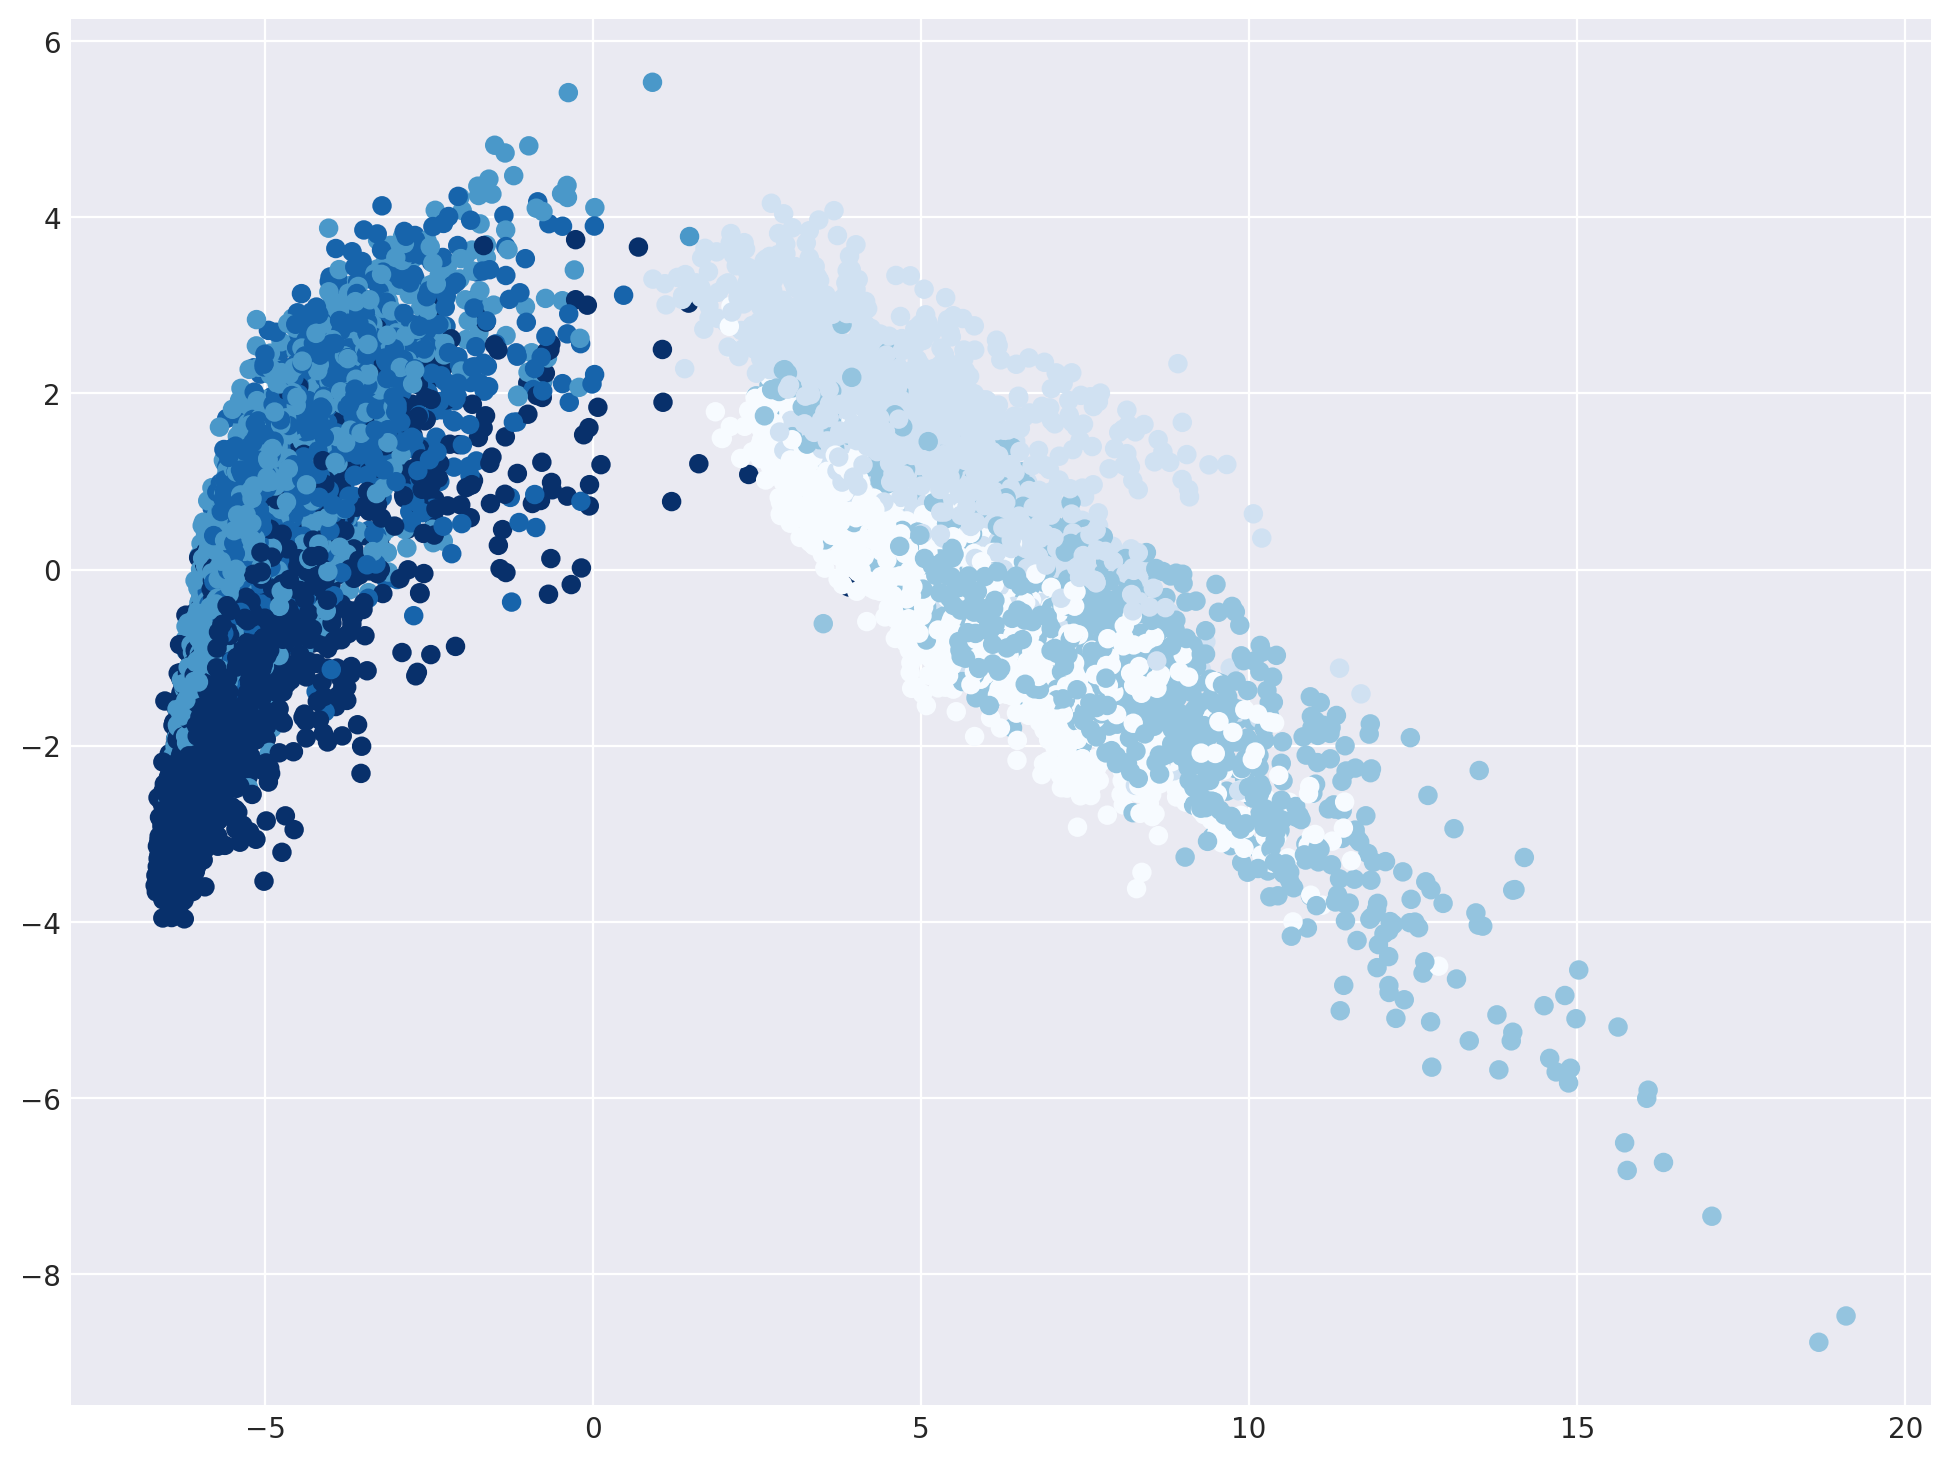

In [25]:
# Ваш код здесь
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Blues')
plt.show()

### **Задание 19. (0.5 балла)**

Разберёмся с `KMeans`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

- Сделайте кластеризацию данных методом `KMeans`, обучив модель на данных со сниженной за счет `PCA` размерностью. Нужно искать 6 кластеров (изначально у нас 6 классов). Засеките время обучения и время инференса.

**Параметры обучения:**

```n_clusters = 6``` (число уникальных меток целевого класса = 6)

```n_init = 100```

```random_state = RANDOM_STATE``` (для воспроизводимости результата, не забывайте указывать его и дальше!)

In [27]:
import time
from sklearn.cluster import KMeans

km = KMeans(n_clusters=6, n_init=100, random_state=RANDOM_STATE)

start = time.time()
km.fit(X_pca)
end = time.time()
print(end-start)

8.672730922698975


### **Задание 20 (0.2 балла)**

- Визуализируйте данные в проекции на первые две главные компоненты.
- Раскрасьте точки в соответствии с полученными метками кластеров.

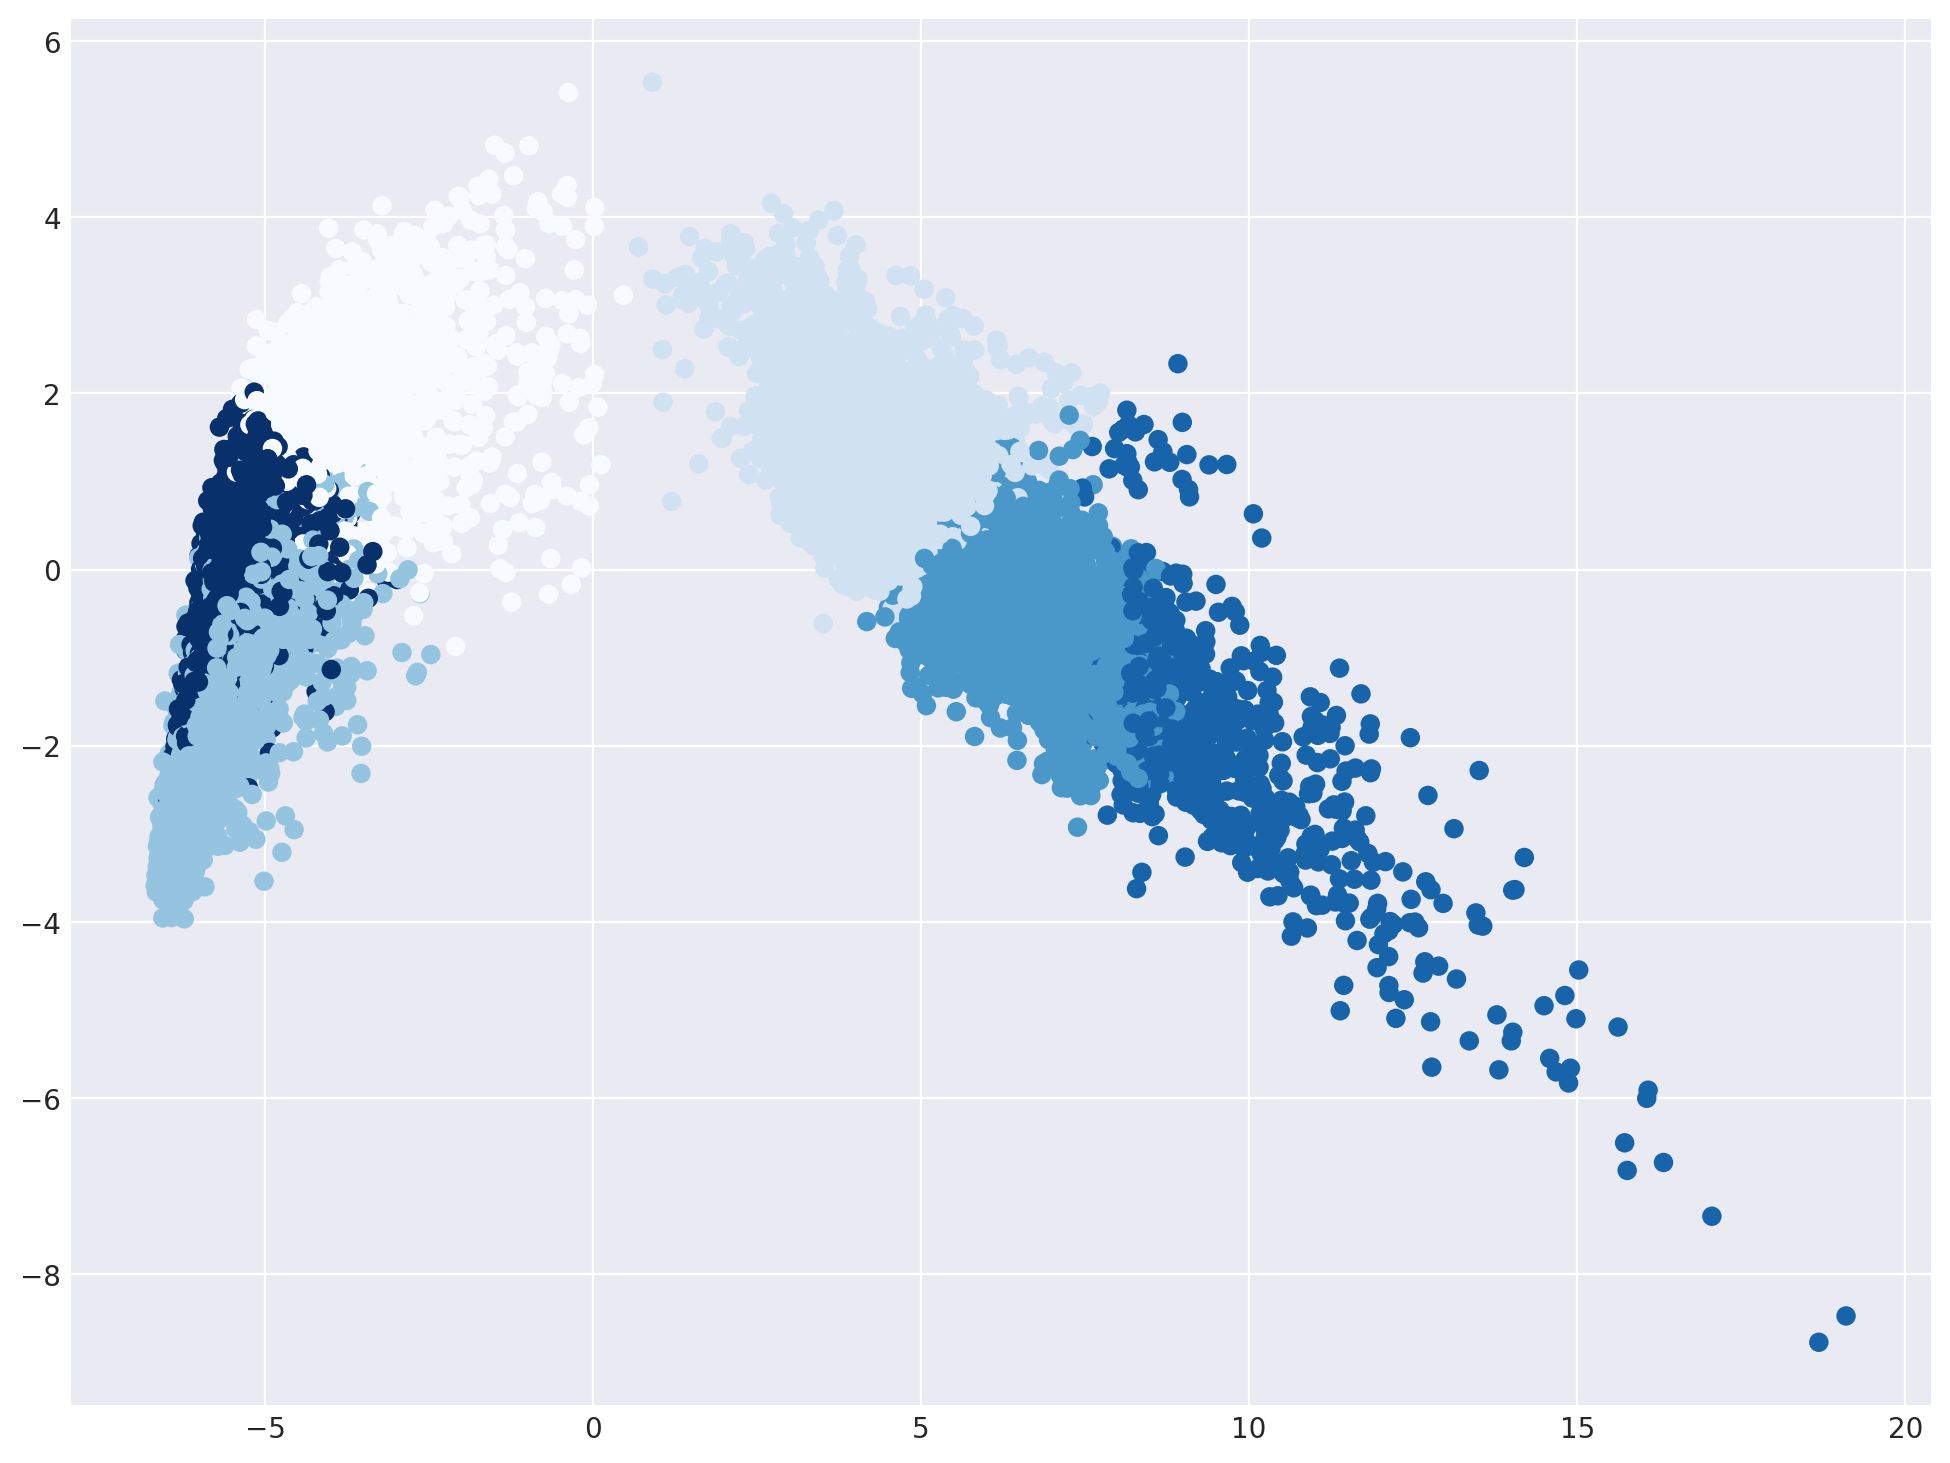

In [ ]:
# Ваш код здесь
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km.labels_, cmap='Blues')
plt.show()

### **Задание 21 (0.3 балла)**

- Выберите какие-то метрики (минимум две) из известных вам. Объясните свой выбор
- Выведите на экран значения метрик качества, сделайте вывод о них и используйте их далее.

In [29]:
from sklearn.metrics import silhouette_score

silhouette_score(X_pca, km.labels_)

np.float64(0.16028296719232615)

In [42]:
from sklearn.metrics import adjusted_rand_score

adjusted_rand_score(y[0], km.labels_)

0.46131718490065227

**Ваш вывод здесь**

### **Задание 22 (0.7 баллов)**

Теперь попробуем сделать кластеризацию с помощью `AgglomerativeClustering`, [doc](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

- Засеките время обучения и время инференса. После кластеризации также:
  - Вновь визуализируйте данные с раскраской по полученным меткам
  - Выведите метрики. Засеките время обучения и время инференса. Сравните с ```KMeans```.

Ответьте на следующие вопросы:
* Стало ли лучше?
* Почему?

In [45]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='ward')
start = time.time()
clusters = agg_clustering.fit_predict(X_pca)
end = time.time()
print(end-start)

6.845471143722534


In [46]:
silhouette_score(X_pca, clusters)

np.float64(0.5161010959302974)

In [47]:
adjusted_rand_score(y[0], clusters)

0.33253220715485143

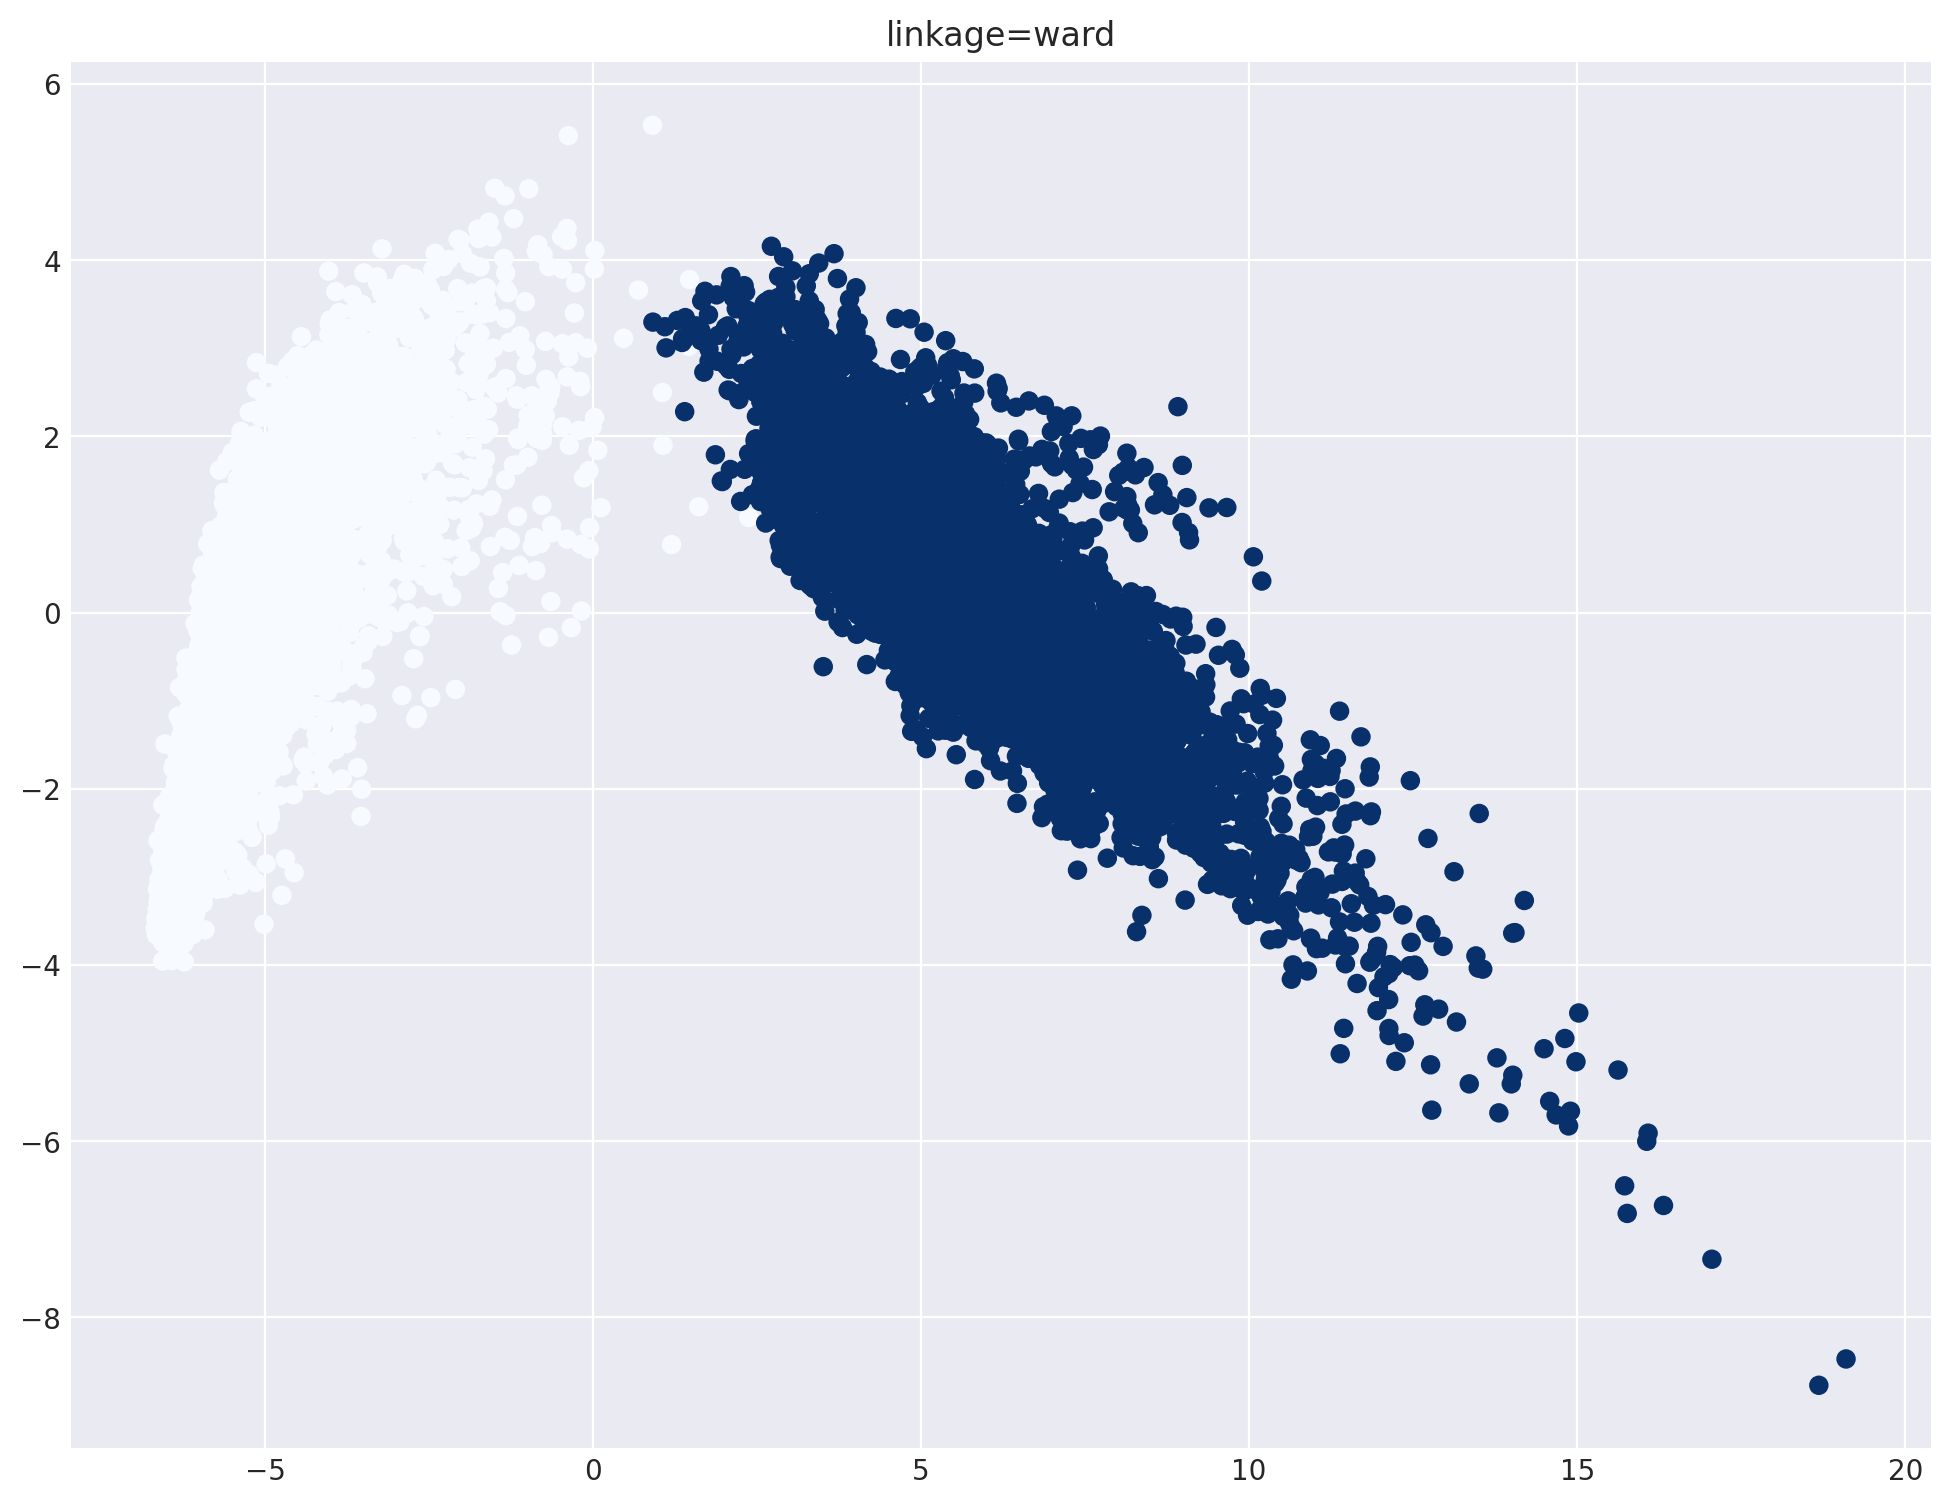

In [48]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Blues')
plt.title('linkage=ward')
plt.show()

**Спасибо! Вы — человек — большой трудяга!**

Успокоительный кот :)

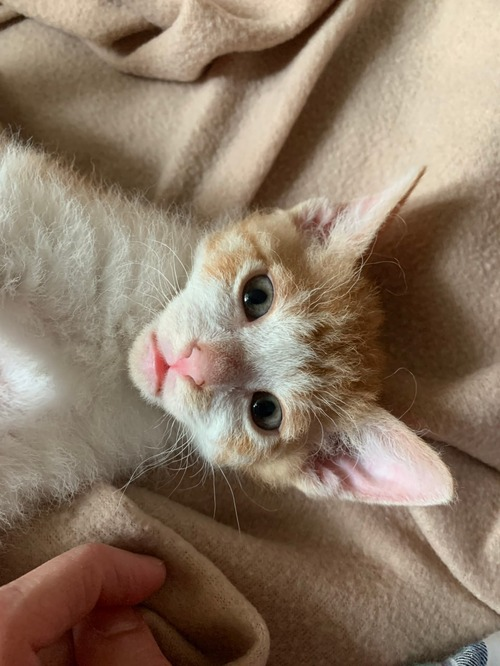